# **1. 규제 선형 회귀 모델/ 회귀 트리**
- 릿지 회귀모델 및 회귀 트리를 이용하여 전복의 나이를 예측해 보세요.

- 전복의 ‘성별’, ‘키’, ‘지름’, ‘높이’, ‘전체무게’, ‘몸통무게’, ‘내장무게’, ‘껍질무게’를 이용해 ‘껍질의 고리수’를 예측한 뒤, **예측된 ‘껍질의 고리수’에 1.5를 더하면 전복의 나이**가 됩니다.

In [1]:
# 기본 모듈 불러오기
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore')

### 1) 데이터 불러오기 및 데이터 선택

In [3]:
# 데이터 로드
data = pd.read_csv("/content/abalone.csv")

# 성별 M은 Male, F는 Female, I는 Infant 이므로 따로 열 만들기
for label in "MFI":
    data[label] = data["Sex"] == label
data.drop('Sex', axis=1, inplace=True)

# X,y 데이터 선택
y = data.Rings.values
data.drop('Rings', axis=1, inplace=True)

X = data.values.astype(float)

## 2) train/test 분리
: 테스트 셋과 데이터 셋을 7:3 비율로 분리하세요.

In [22]:
# 필요한 모듈 불러오기
from sklearn.model_selection import train_test_split

In [23]:
# train과 test set 분리 (train:test = 7:3 비율로)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=23)

## 3) 릿지 모델을 이용한 모델링
: 릿지 모델을 이용하여 전복의 나이를 예측해 보고 결과를 평가해 보세요.

 3-1) 릿지모델 생성, 교차검증, 평가에 필요한 모듈을 불러오세요.

In [24]:
#필요한 모듈 불러오기
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

3-2) 릿지 모델을 생성하고 훈련하여 MSE와 RMSE를 구하세요. 릿지 모델 생성 시  alpha는 0.3으로 설정합니다. (교차 검증 하지 않습니다.)

In [26]:
#릿지모델 생성 및 훈련
ridge = Ridge(alpha=0.3)
ridge.fit(X_train, y_train)

#예측값 구하기
pred_rings = ridge.predict(X_test)

#구한 예측값을 활용해 최종적으로 전복의 나이 예측
pred_age = pred_rings + 1.5
actual_age = y_test + 1.5

#MSE와 RMSE구하기
mse = mean_squared_error(actual_age, pred_age)
rmse = np.sqrt(mse)
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MSE: 5.0029
RMSE: 2.2367


3-3) 릿지 모델에서 회귀 계수 값을 구해 알 수 있는 점을 작성하시오. (각 컬럼의 정보는 data.colums 참고)

In [27]:
data.columns

Index(['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'M', 'F', 'I'],
      dtype='object')

- 회귀 계수 부호: 각 독립변수가 전복의 나이에 미치는 영향력과 방향
- +: 값이 커질수록 전복의 나이가 많아질 가능성이 높음
- -: 값이 커질수록 전복의 나이가 적어질 가능성이 높음

3-3) 교차검증을 이용하여 0, 0.1, 1, 10, 100 중  모델 성능이 가장 좋게 나오는 (rmse가 최소가 되는) alpha를 구하세요.

In [28]:
# 주어진 alpha
alphas=[0, 0.1, 1, 10, 100]

In [35]:
#alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함
for alpha in alphas:
    ridge_cv = Ridge(alpha=alpha)

    #cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산
    neg_mse_scores = cross_val_score(ridge_cv, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
    rmse_scores = np.sqrt(-neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)

    print(f"alpha {alpha}의 5-Fold 평균 RMSE: {avg_rmse:.4f}")

alpha 0의 5-Fold 평균 RMSE: 2.1827
alpha 0.1의 5-Fold 평균 RMSE: 2.1826
alpha 1의 5-Fold 평균 RMSE: 2.1969
alpha 10의 5-Fold 평균 RMSE: 2.3442
alpha 100의 5-Fold 평균 RMSE: 2.5985


## 4) XGBRegressor을 이용한 모델링
: XGBRegressor 모델을 이용하여 전복의 나이를 예측해 보고 결과를 평가해 보세요.

4-1) XGBRegressor 훈련, 평가에 필요한 모듈을 불러오세요.

In [37]:
# 필요한 모듈 임포트
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor


4-2) XGBregressor 모델을 생성하고 훈련하여 MSE와 RMSE를 구하세요.

In [38]:
#모델 생성 및 훈련
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

#예측값 구하기
pred = xgb.predict(X_test)
#구한 예측값을 활용해 최종적으로 전복의 나이 예측
pred = pred + 1.5

#MSE와 RMSE 구하기
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)


4-3) 생성한 모델의 피처 중요도를 시각화해보세요.

<Axes: xlabel='None', ylabel='None'>

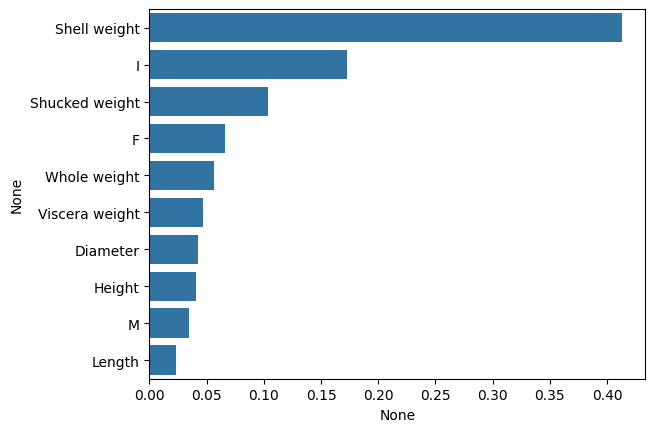

In [39]:
import seaborn as sns
%matplotlib inline
feature_names = data.columns
feature_series = pd.Series(data=xgb.feature_importances_, index=feature_names)
feature_series = feature_series.sort_values(ascending=False)
sns.barplot(x=feature_series, y=feature_series.index)


---

# **2. 로지스틱 회귀분석**
load_wine() 함수를 이용하여 와인 데이터를 다항분류하는 로지스틱 회귀모델을 생성하세요.

In [4]:
# 필요한 모듈 불러오기
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

## 1) 데이터 불러오기 및 변수 선택

In [11]:
wine = load_wine()

wine_x = wine.data # x변수
wine_y = wine.target # y변수

## 2) train/test 셋 분리

In [12]:
# 30%는 test으로 설정
x_train, x_test, y_train, y_test = train_test_split(wine_x, wine_y, test_size=0.3, random_state=123)

# 전체 178개 데이터 중 124(0.7)개 샘플과 13개 피처
x_train.shape
# 124개 샘플에 대한 정답 데이터
y_train.shape
print(x_train.shape)

print(y_train.shape)

(124, 13)
(124,)


## 3) 로지스틱 회귀모델을 이용한 모델링

3-1) 로지스틱 회귀모델을 생성하여 훈련하세요.

In [14]:
#생성하기
model = LogisticRegression(max_iter=10000, random_state=123)
#훈련하기
model.fit(x_train, y_train)

LogisticRegression(max_iter=10000, random_state=123)

3-2) 회귀 모델의 기울기와 절편을 구하세요.

In [18]:
#기울기
print(model.coef_)

[[ 0.42439298  0.54744452  0.62026175 -0.25946906 -0.00207495  0.25257608
   0.75790461  0.09118418  0.14341218  0.1758945  -0.01150508  0.51869373
   0.00865839]
 [-0.61350726 -0.91046142 -0.69744893  0.14881052 -0.04174846  0.31231432
   0.15345516  0.03003637  0.39268846 -0.9168763   0.32597234  0.13224331
  -0.00767599]
 [ 0.18911428  0.3630169   0.07718717  0.11065854  0.0438234  -0.5648904
  -0.91135977 -0.12122055 -0.53610064  0.7409818  -0.31446726 -0.65093704
  -0.0009824 ]]


In [19]:
#절편
print(model.intercept_)

[-13.57617163  21.30986693  -7.73369529]


3-3) 모델의 정확도를 구하세요.

In [21]:
#모델의 예측값 구하기
y_pred = model.predict(x_test)
print(y_pred)
#모델의 정확도 구하기
accuracy = metrics.accuracy_score(y_test, y_pred)
print(accuracy)

[2 1 2 1 1 2 0 2 2 1 2 2 2 0 0 2 1 1 0 1 2 2 2 2 1 2 2 0 0 0 0 0 1 1 2 1 2
 0 1 1 2 2 0 0 1 0 0 1 0 1 1 2 2 1]
0.9629629629629629
